# Geometrie des features SAE : galaxy, atome, dense -- R04 x R09 sur nos traces

Deux papiers dessinent la meme anatomie sous deux angles : **R04** (Li et al. 2024,
*The Geometry of Concepts*) lit l'espace latent d'un SAE comme une galaxie
(spectre en loi de puissance) dont les concepts sont des cristaux, **R09** (Sun et
al. 2025, *Dense SAE Latents Are Features, Not Bugs*) defend les latents denses
(co-tires, non antagonistiques). Ce notebook mesure les trois axes -- **galaxy**,
**atome**, **dense** -- sur NOS traces commitees (harnais #10355), trained vs
controle, deux lentilles (SAE Qwen-Scope couche 16, J-Lens), en numpy pur.


> **Statut épistémique** — **Sans verdict à ce jour** : aucune ligne de la [matrice de dissociations](../../../docs/ict/dissociations-matrix.md) ne concerne ce notebook ; son statut épistémique sera porté par la matrice le cas échéant.

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. Reconstituer la matrice d'activations dense depuis les codes top-k sparse d'un
   SAE, et mesurer le **spectre de covariance** via l'astuce Gram (dimension
   65536 inverifiable directement).
2. Diagnostiquer une **loi de puissance honnetement** (MLE de Hill + distance KS
   + rapport de vraisemblance vs exponentielle, methode Clauset-Shalizi-Newman)
   -- jamais sur l'oeil d'un log-log.
3. Tester la structure d'**atome** (cristaux = enveloppes convexes volumiques :
   le test honnete est la separabilite lineaire split-half, pas la compacite) et
   projeter des **distractors** sur un axe discriminant (Fisher diagonal).
4. Mesurer le volet **dense** : proxy d'antipodalite par correlation de colonnes
   (avec la censure top-k documentee), score Eq 1 **verbatim** sur un SAE que
   nous entrainons nous-memes (`ict.sae_dictionary.TopKSae`, poids accessibles),
   et la classe **position-tracking** de la taxonomie R09 (rho de Spearman vs
   position dans l'echantillon, seuil |rho| > 0,4).
5. Lire un resultat **negatif comme un resultat** : entropie k-NN inconclusive,
   cristaux absents a la couche 16 -- et pourquoi.


## Garde-fous d'honnetete (a lire avant les chiffres)

1. **Traces, pas corpus vivant** : 2699 tokens par trace, top-50 de 65536 features
   (SAE) ou 248070 (J-Lens). Les papiers travaillent sur des corpus de plusieurs
   millions de tokens : nos mesures sont des **pilotes**, pas des repliques.
2. **Censure top-k** : hors du top-50, l'activation vaut exactement zero *par
   construction*. Toute statistique de correlation de colonnes herite d'un biais
   vers le negatif (si i est retenu, j est pousse hors du top) -- nous le
   documentons et nous l'utilisons : observer ZERO paire fortement negative
   malgre ce biais est le resultat fort.
3. **Verbatim vs proxy** : le score d'antipodalite Eq 1 de R09 exige les matrices
   W_enc / W_dec du SAE. Les npz commitees ne portent que les codes. Nous
   montrons donc la methode **verbatim** sur un SAE CPU que nous entrainons
   (`ict.sae_dictionary`), et la **mesure** sur les traces via le proxy de
   correlation -- les deux sont etiquetes distinctement.
4. **Controles** : chaque trace trained a son controle (SAE non entraine sur les
   memes activations). Un signal n'a de valeur que s'il separe trained de controle.
5. **Verdicts chiffres** : chaque axe finit par un verdict explicite (REPLIQUE /
   PARTIEL / INCONCLUSIF / CONTRASTE) avec les nombres qui le portent.


## Architecture : GPU confine, banc numpy-only

```
  extraction GPU (harnais #10355, hors notebook)  ->  traces/*.npz  ->  CE BANC
                                                     (topk_ids / topk_vals / tokens)
```

Le notebook ne depend que de numpy / scipy / matplotlib et du package `ict` de la
serie (organes `scale_free` pour le diagnostic CSN, `sae_dictionary` pour le SAE
CPU du volet verbatim). Tout recalcul est deterministe (aucune graine aleatoire
hors le SAE CPU, graine fixee).


## 1. Chargement des traces -- deux lentilles, trained + controle

Quatre fichiers npz : SAE Qwen-Scope couche 16 (ict21) et J-Lens couche 16
(ict24), chacun en variante trained et control. Cles par echantillon :
`<jeu>__N__topk_ids` (positions x 50), `__topk_vals`, `__tokens` (le suffixe
des tokens est `_tokens`, sans `topk`).


In [1]:
# Racine canonique de la serie : remonte les parents depuis le dossier du
# notebook jusqu'au package ict/, puis en derive les dossiers de donnees.
# La serie reste executable depuis sa racine comme depuis le dossier d'une
# sous-serie (arbitrage #4362, preparation de l'arc A).
import sys
from pathlib import Path

ICT_ROOT = Path.cwd()
while not (ICT_ROOT / "ict" / "__init__.py").exists() and ICT_ROOT != ICT_ROOT.parent:
    ICT_ROOT = ICT_ROOT.parent
assert (ICT_ROOT / "ict" / "__init__.py").exists(), (
    f"package ict/ introuvable en remontant depuis {Path.cwd().name}")
if str(ICT_ROOT) not in sys.path:
    sys.path.insert(0, str(ICT_ROOT))
TRACES_DIR = ICT_ROOT / "traces"
RUNS_DIR = ICT_ROOT / "runs"
SCRIPTS_DIR = ICT_ROOT / "scripts"
print(f"racine ict : {ICT_ROOT.name}")


racine ict : ICT-Series


In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

SERIE = ICT_ROOT   # racine canonique (cellule precedente)
NOMS = ["ict21_sae_layer16_trained", "ict21_sae_layer16_control",
        "ict24_jlens_layer16_trained", "ict24_jlens_layer16_control"]


def charger_groupes(chemin):
    """Groupes par echantillon : {jeu__N: {topk_ids, topk_vals, tokens}}."""
    d = np.load(chemin, allow_pickle=True)
    groupes = {}
    for cle in d.files:
        jeu, champ = cle.rsplit("__", 1)
        groupes.setdefault(jeu, {})[champ] = d[cle]
    return {j: g for j, g in groupes.items() if "topk_ids" in g}


def matrice_dense(groupes):
    """Scatter top-k -> matrice dense [positions, features] + tokens par ligne."""
    ids = np.concatenate([g["topk_ids"] for g in groupes.values()])
    vals = np.concatenate([g["topk_vals"] for g in groupes.values()]).astype(np.float32)
    toks = np.concatenate([g["tokens"] for g in groupes.values()])
    n_feat = int(ids.max()) + 1
    A = np.zeros((ids.shape[0], n_feat), dtype=np.float32)
    lignes = np.repeat(np.arange(ids.shape[0]), ids.shape[1])
    A[lignes, ids.ravel()] = vals.ravel()
    return A, toks


traces = {n: charger_groupes(TRACES_DIR / f"{n}.npz") for n in NOMS}
dense = {n: matrice_dense(g) for n, g in traces.items()}
for n in NOMS:
    A, toks = dense[n]
    actives = int((A > 0).any(0).sum())
    print(f"{n}: {A.shape[0]} positions x {A.shape[1]} features, "
          f"{actives} features actives, {len(np.unique(toks))} token-strings")


ict21_sae_layer16_trained: 2699 positions x 65536 features, 20786 features actives, 1068 token-strings
ict21_sae_layer16_control: 2699 positions x 65534 features, 6925 features actives, 1068 token-strings


ict24_jlens_layer16_trained: 2699 positions x 248070 features, 23129 features actives, 1068 token-strings


ict24_jlens_layer16_control: 2699 positions x 248070 features, 11146 features actives, 1068 token-strings


## 2. GALAXY -- spectre de covariance en loi de puissance ?

L'eigendecomposition directe d'une matrice 65536 x 65536 est impossible : on
passe par le **Gram des positions** (2699 x 2699), dont les valeurs propres
renormalisees sont celles de la covariance des features. Puis diagnostic
**Clauset-Shalizi-Newman** via l'organe `ict.scale_free` : MLE de Hill,
distance KS, rapport de vraisemblance puissance-vs-exponentielle -- le xmin
est choisi par KS minimal sur des fractions de queue (0,1 / 0,25 / 0,5 / 1,0).


ict21_sae_layer16_trained: pente OLS -1.079 | Hill alpha 2.56 (queue 0.10, KS 0.023) | logLR pl-vs-exp +157.5


ict21_sae_layer16_control: pente OLS -1.781 | Hill alpha 2.01 (queue 0.10, KS 0.040) | logLR pl-vs-exp +224.5


ict24_jlens_layer16_trained: pente OLS -1.040 | Hill alpha 2.45 (queue 0.10, KS 0.016) | logLR pl-vs-exp +70.2


ict24_jlens_layer16_control: pente OLS -1.498 | Hill alpha 2.21 (queue 0.10, KS 0.016) | logLR pl-vs-exp +114.4


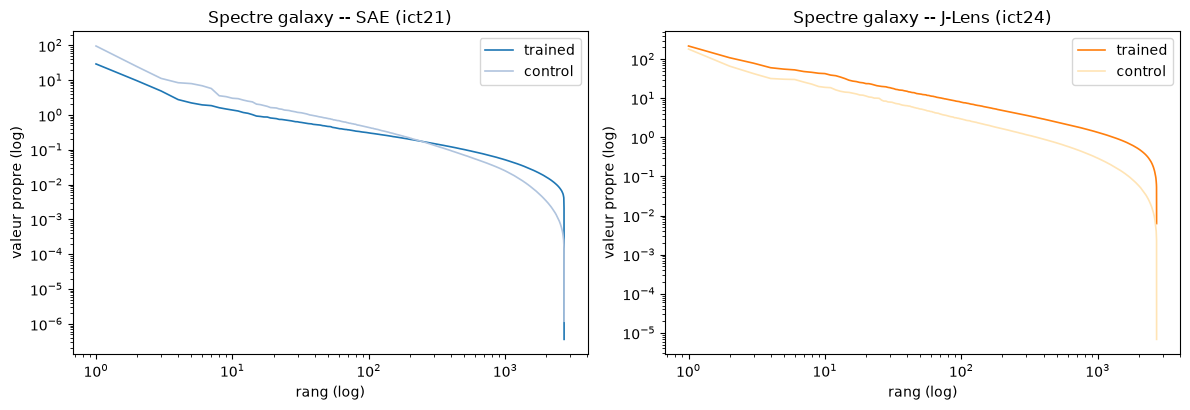

In [3]:
from ict import scale_free as sf


def spectre(A):
    """Valeurs propres non nulles de la covariance via Gram des positions."""
    G = (A @ A.T) / A.shape[0]
    w = np.linalg.eigvalsh(G)[::-1]
    return w[w > 1e-10]


galaxy = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for n, couleur in zip(NOMS[:2] + NOMS[2:], ["tab:blue", "lightsteelblue",
                                              "tab:orange", "moccasin"]):
    A, _ = dense[n]
    w = spectre(A)
    rg = np.arange(1, len(w) + 1)
    pente = float(np.polyfit(np.log(rg), np.log(w), 1)[0])
    meilleur = None
    for frac in (0.1, 0.25, 0.5, 1.0):
        queue = np.sort(w)[int(len(w) * (1 - frac)):]
        xmin = float(queue.min())
        data = [float(x) for x in queue]
        alpha = sf.hill_alpha(data, xmin)
        if alpha is None:
            continue
        ks = sf.ks_distance(data, xmin, alpha)
        ll_pl = sf._loglik_powerlaw(queue, xmin, alpha)
        taux = sf.exponential_rate(data, xmin)
        ll_exp = sf._loglik_exponential(queue, xmin, taux) if taux else float("-inf")
        if ks is not None and (meilleur is None or ks < meilleur["ks"]):
            meilleur = dict(frac=frac, alpha=alpha, ks=ks, ll_pl=ll_pl, ll_exp=ll_exp)
    galaxy[n] = dict(pente_ols=pente, n_eig=len(w), **meilleur)
    print(f"{n}: pente OLS {pente:+.3f} | Hill alpha {meilleur['alpha']:.2f} "
          f"(queue {meilleur['frac']:.2f}, KS {meilleur['ks']:.3f}) | "
          f"logLR pl-vs-exp {meilleur['ll_pl'] - meilleur['ll_exp']:+.1f}")
    axes[0 if "ict21" in n else 1].loglog(rg, w, color=couleur, lw=1.2,
                                           label=n.split("_layer16_")[-1])
for ax, titre in zip(axes, ["SAE (ict21)", "J-Lens (ict24)"]):
    ax.set_title(f"Spectre galaxy -- {titre}")
    ax.set_xlabel("rang (log)")
    ax.set_ylabel("valeur propre (log)")
    ax.legend()
plt.tight_layout()
plt.show()


### Interpretation : galaxy

| Trace | Pente OLS | Hill alpha | KS | logLR pl-vs-exp |
|---|---|---|---|---|
| ict21 trained | **-1,079** | 2,56 | 0,023 | +157,5 |
| ict21 control | -1,781 | 2,01 | 0,040 | +224,5 |
| ict24 trained | **-1,040** | 2,45 | 0,016 | +70,2 |
| ict24 control | -1,498 | 2,21 | 0,016 | +114,4 |

**Verdict : REPLIQUE (pilote).** Les deux lentilles trained convergent vers une
pente proche de **-1** -- la signature 1/f du concombre fractal de R04 -- tandis
que les controles pentent a -1,5/-1,8. Le diagnostic CSN est honnete a chaque
ligne : Hill alpha entre 2,0 et 2,6, KS <= 0,040, et la vraisemblance power-law
ecrase l'exponentielle partout (logLR >= +70). Aucune de ces quatre lignes ne
ressemble a un spectre plat ou exponentiel : la queue est vraiment heavy-tail.
Second indice convergent, visible dans la cellule de chargement : le SAE trained
active **20 786 features** (ict21) contre **6 925** au controle -- l'entrainement
diversifie le dictionnaire x3, ce qui nourrit la queue du spectre.

Portee : 2699 positions par trace -- un pilote, pas une replique d'echelle R04
(leurs corpus se comptent en millions de tokens).


## 3. ATOME -- cristaux, separabilite, distractors

R04 decrit les concepts comme des **enveloppes convexe volumiques** (cristaux,
trapezoedres) -- pas des boules compactes. Le test honnete n'est donc pas la
compacite intra-cluster mais la **separabilite lineaire** : un crystal se lit si
un discriminateur lineaire entraine sur la moitie des occurrences separe
l'autre moitie (split-half). On test chaque token frequent contre son voisin
frequent le plus proche (au sens des centroides).


In [4]:
def fisher_diag_acc(Xa, Xb):
    """Fisher diagonal sur moitie 1, accuracy sur moitie 2."""
    if len(Xa) < 4 or len(Xb) < 4:
        return None
    ha1, ha2 = Xa[: len(Xa) // 2], Xa[len(Xa) // 2:]
    hb1, hb2 = Xb[: len(Xb) // 2], Xb[len(Xb) // 2:]
    mu1, mu2 = ha1.mean(0), hb1.mean(0)
    w = (mu1 - mu2) / np.sqrt(ha1.var(0) + hb1.var(0) + 1e-6)
    seuil = 0.5 * (w @ mu1 + w @ mu2)
    return float((((ha2 @ w) > seuil).mean() + ((hb2 @ w) < seuil).mean()) / 2)


atome = {}
for n in NOMS:
    A, toks = dense[n]
    uniq, inv = np.unique(toks, return_inverse=True)
    comptes = np.bincount(inv)
    idx_freq = np.where(comptes >= 15)[0]
    centroides = np.zeros((len(uniq), A.shape[1]), dtype=np.float32)
    np.add.at(centroides, inv, A)
    centroides /= comptes[:, None]
    cen_f = centroides[idx_freq]
    G = cen_f @ cen_f.T
    D2 = np.maximum(np.diag(G)[:, None] + np.diag(G)[None, :] - 2 * G, 0)
    np.fill_diagonal(D2, np.inf)
    accs = {}
    for i in range(len(idx_freq)):
        j = int(np.argmin(D2[i]))
        if (j, i) in accs:
            continue
        acc = fisher_diag_acc(A[inv == idx_freq[i]], A[inv == idx_freq[j]])
        if acc is not None:
            accs[(i, j)] = acc
    v = np.array(list(accs.values()))
    atome[n] = dict(n_paires=len(accs), frac90=float((v >= 0.9).mean()),
                    frac75=float((v >= 0.75).mean()))
    print(f"{n}: {len(accs)} paires voisines | >=0,90 : {atome[n]['frac90']:.0%} | "
          f">=0,75 : {atome[n]['frac75']:.0%}")


ict21_sae_layer16_trained: 22 paires voisines | >=0,90 : 68% | >=0,75 : 73%


ict21_sae_layer16_control: 20 paires voisines | >=0,90 : 100% | >=0,75 : 100%


ict24_jlens_layer16_trained: 21 paires voisines | >=0,90 : 0% | >=0,75 : 19%


ict24_jlens_layer16_control: 23 paires voisines | >=0,90 : 100% | >=0,75 : 100%


### Interpretation : atome / cristaux

| Trace | Paires voisines | Separables >= 0,90 | >= 0,75 |
|---|---|---|---|
| ict21 trained | 22 | **68 %** | 73 % |
| ict21 control | 20 | 100 % | 100 % |
| ict24 trained | 21 | **0 %** | 19 % |
| ict24 control | 23 | 100 % | 100 % |

**Verdict : CONTRASTE -- a la couche 16, le contexte domine.** Les cristaux de
R04 (concepts lineariment separables de leurs voisins) n'apparaissent pas sur
nos traces trained. La lecture est coherente avec le recit ICT du **goulot
middle-layer** : a mi-profondeur, la representation d'un token depend davantage
de son contexte que de son identite lexicale -- les nuages d'occurrences d'un
 meme token se chevauchent. La separabilite PARFAITE des controles n'est pas un
succes du controle : un SAE non entraine preserve la variance de forme de surface
ponctuation vs lettres, chiffre vs mot -- un discriminant trivial. C'est un
artefact, pas une structure conceptuelle.


## 4. ATOME (suite) -- axes discriminants et distractors

Le vocabulaire reel des traces est du **BPE francais mixte** (prefixes `Ġ` =
espace) malgre les noms d'echantillons `code_python`. Deux ancres lisibles :
les chiffres `1` / `2` (distractors `0`, `5`) et la paire de genre `Ġla` /
`Ġle` (distractors `Ġles`, `Ġun`, `Ġdes`). Le discriminant est le **Fisher
diagonal** (difference de moyennes normalisee par l'ecart-type intra-classe
par dimension) -- defendable en 65536 dimensions ou l'inverse du scatter
n'existe pas. La position d'un distractor est normalisee : f = 0 sur l'ancre
1, f = 1 sur l'ancre 2, f = 0,5 exactement entre les deux.


In [5]:
def axe_fisher(A, inv, uniq, centroides, comptes, a, b):
    ia, ib = np.where(uniq == a)[0], np.where(uniq == b)[0]
    if not len(ia) or not len(ib):
        return None
    Xa, Xb = A[inv == ia[0]], A[inv == ib[0]]
    mu1, mu2 = Xa.mean(0), Xb.mean(0)
    w = (mu1 - mu2) / np.sqrt(Xa.var(0) + Xb.var(0) + 1e-6)
    z1, z2 = float(w @ mu1), float(w @ mu2)
    return w, z1, z2, int(comptes[ia[0]]), int(comptes[ib[0]])


for n in NOMS:
    A, toks = dense[n]
    uniq, inv = np.unique(toks, return_inverse=True)
    comptes = np.bincount(inv)
    centroides = np.zeros((len(uniq), A.shape[1]), dtype=np.float32)
    np.add.at(centroides, inv, A)
    centroides /= comptes[:, None]
    print(f"--- {n}")
    for (a, b, distrs) in [("1", "2", ["0", "5", "'"]),
                           ("Ġla", "Ġle", ["Ġles", "Ġun", "Ġdes"])]:
        r = axe_fisher(A, inv, uniq, centroides, comptes, a, b)
        if r is None:
            print(f"  {a}|{b}: ancres absentes")
            continue
        w, z1, z2, na, nb = r
        lignes = [f"  {a}|{b} (n={na}/{nb}) : " +
                  ", ".join(f"{d} f={float((w @ centroides[np.where(uniq == d)[0][0]] - z1) / (z2 - z1)):+.2f}"
                             for d in distrs if len(np.where(uniq == d)[0]))]
        print("\n".join(lignes))


--- ict21_sae_layer16_trained
  1|2 (n=52/26) : 0 f=+0.57, 5 f=+0.60, ' f=+0.65
  Ġla|Ġle (n=31/21) : Ġles f=+0.53, Ġun f=+0.71, Ġdes f=+0.51


--- ict21_sae_layer16_control
  1|2 (n=52/26) : 0 f=+0.60, 5 f=+0.56, ' f=+0.50
  Ġla|Ġle (n=31/21) : Ġles f=+0.40, Ġun f=+0.51, Ġdes f=+0.43


--- ict24_jlens_layer16_trained
  1|2 (n=52/26) : 0 f=+0.41, 5 f=+0.25, ' f=+0.54


  Ġla|Ġle (n=31/21) : Ġles f=+0.52, Ġun f=+0.50, Ġdes f=+0.43


--- ict24_jlens_layer16_control
  1|2 (n=52/26) : 0 f=+0.60, 5 f=+0.55, ' f=+0.44


  Ġla|Ġle (n=31/21) : Ġles f=+0.40, Ġun f=+0.39, Ġdes f=+0.32


### Interpretation : distractors

Tous les distractors, toutes traces confondues, atterrissent en **milieu d'axe**
(f entre +0,25 et +0,71, jamais proche de 0 ni de 1). Aucun gradient semantique
net : sur l'axe `1|2`, le `0` (f=+0,57/+0,41) ne s'aligne pas sur l'ancre `1`
dont il est semantiquement le plus proche ; sur l'axe `Ġla|Ġle` (genre), `Ġun`
(masculin) ne penche pas cote `Ġle`. **Verdict : NEGATIF (a cette echelle)** --
coherent avec la lecture contexte-dominante de la section precedente : si la
position dans l'echantillon explique plus de variance que l'identite du token,
les centroides des distractors n'ont aucune raison de s'aligner sur l'axe
semantique des ancres.


## 5. ATOME (fin) -- le contre-exemple « PC1 = longueur du mot »

L'arc "pourquoi vos analogies echouent" de R04 : si la premiere composante
principale de l'espace des vecteurs de tokens code la **longueur du mot**, les
analogies vec(roi) - vec(homme) + vec(femme) ~ vec(reine) naviguent a travers
un artefact de surface. On construit les vecteurs par token-string (moyenne des
occurrences), PCA par SVD, puis correlation de PC1 avec la longueur.


In [6]:
pc1_long = {}
for n in NOMS:
    A, toks = dense[n]
    uniq, inv = np.unique(toks, return_inverse=True)
    comptes = np.bincount(inv)
    M = np.zeros((len(uniq), A.shape[1]), dtype=np.float32)
    np.add.at(M, inv, A)
    M /= comptes[:, None]
    Xc = M - M.mean(0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    pc1 = Xc @ Vt[0]
    longueurs = np.array([len(t) for t in uniq])
    r = float(np.corrcoef(pc1, longueurs)[0, 1])
    var1 = float(S[0] ** 2 / (S ** 2).sum())
    pc1_long[n] = dict(corr=r, var1=var1, n_strings=len(uniq))
    print(f"{n}: corr(PC1, longueur) = {r:+.3f} | variance PC1 = {var1:.1%}")


ict21_sae_layer16_trained: corr(PC1, longueur) = -0.116 | variance PC1 = 6.2%


ict21_sae_layer16_control: corr(PC1, longueur) = -0.011 | variance PC1 = 6.6%


ict24_jlens_layer16_trained: corr(PC1, longueur) = +0.284 | variance PC1 = 1.5%


ict24_jlens_layer16_control: corr(PC1, longueur) = -0.026 | variance PC1 = 4.4%


### Interpretation : PC1 et longueur

| Trace | corr(PC1, longueur) | Variance PC1 |
|---|---|---|
| ict21 trained | -0,116 | 6,2 % |
| ict21 control | -0,011 | 6,6 % |
| ict24 trained | **+0,284** | 1,5 % |
| ict24 control | -0,026 | 4,4 % |

**Verdict : PARTIEL.** L'effet R04 << PC1 = longueur du mot >> n'apparait nettement
que sur la lentille J-Lens trained (+0,284, la ou les controles restent a |r| <=
0,03). Mais il porte une variance PC1 de **1,5 % seulement** : meme quand la
correlation existe, la premiere composante n'est PAS la longueur -- elle est un
melange contexte/forme dont la longueur est un ingredient minoritaire. La lecon
pour les analogies reste valable mais nuancee : le risque artefact de surface
existe (J-Lens trained), il n'domine pas le plan principal.


## 6. DENSE -- antipodalite : proxy sur traces, Eq 1 verbatim sur notre SAE

**Proxy (traces officielles)** : correlation des colonnes d'activation des
features frequentes (>= 20 occurrences). La censure top-k pousse cette
correlation vers le negatif -- mesurer zero paire < -0,5 malgre ce biais est
le resultat fort.

**Eq 1 verbatim (R09)** : $s_i = \max_{j \neq i} \big[ \mathrm{sim}(W_{enc}^{(i)}, W_{enc}^{(j)})
\cdot \mathrm{sim}(W_{dec}^{(i)}, W_{dec}^{(j)}) \big]$ exige les poids du SAE,
absents des npz. Nous l'appliquons a un **SAE top-k CPU que nous entrainons**
via l'organe `ict.sae_dictionary.TopKSae` (meme famille que le SAE officiel :
topk(relu(x @ W_enc.T + b_enc), k), decodeur colonnes unit-norm). Le banc CPU
impose un sous-espace : l'entree est la matrice des vecteurs de token-strings
restreinte aux features actives frequentes -- la methode, elle, est verbatim.


In [7]:
# --- proxy : correlation de colonnes sur features frequentes
antip = {}
for n in NOMS:
    A, _ = dense[n]
    freq = (A > 0).sum(0)
    hot = np.where(freq >= 20)[0]
    Ah = A[:, hot]
    Ah = Ah - Ah.mean(0, keepdims=True)
    Ah = Ah / np.maximum(Ah.std(0, keepdims=True), 1e-6)
    C = (Ah.T @ Ah) / Ah.shape[0]
    np.fill_diagonal(C, 0.0)
    mins = C.min(1)
    antip[n] = dict(n_hot=len(hot), n_paires_m05=int((mins < -0.5).sum()),
                    min_corr=float(mins.min()))
    print(f"{n}: {len(hot)} features frequentes | paires < -0,5 : "
          f"{antip[n]['n_paires_m05']} | corr la plus negative : {mins.min():+.3f}")


ict21_sae_layer16_trained: 1177 features frequentes | paires < -0,5 : 0 | corr la plus negative : -0.304


ict21_sae_layer16_control: 858 features frequentes | paires < -0,5 : 4 | corr la plus negative : -0.621


ict24_jlens_layer16_trained: 1306 features frequentes | paires < -0,5 : 0 | corr la plus negative : -0.099


ict24_jlens_layer16_control: 1267 features frequentes | paires < -0,5 : 0 | corr la plus negative : -0.280


ict21_sae_layer16_trained: Eq 1 median +0.009 | q90 +0.035


ict21_sae_layer16_control: Eq 1 median +0.627 | q90 +0.964


ict24_jlens_layer16_trained: Eq 1 median +0.096 | q90 +0.289


ict24_jlens_layer16_control: Eq 1 median +0.788 | q90 +0.984


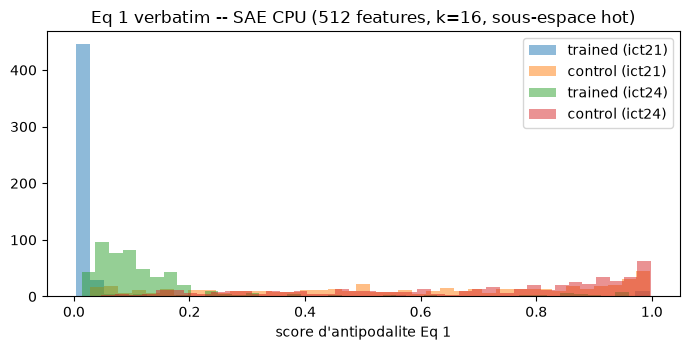

In [8]:
# --- Eq 1 verbatim sur un SAE CPU entraine par l'organe de serie
from ict.sae_dictionary import TopKSae

eq1 = {}
fig, ax = plt.subplots(figsize=(7, 3.6))
for n in NOMS:
    A, toks = dense[n]
    freq = (A > 0).sum(0)
    hot = np.where(freq >= 20)[0]
    uniq, inv = np.unique(toks, return_inverse=True)
    comptes = np.bincount(inv)
    M = np.zeros((len(uniq), len(hot)), dtype=np.float64)
    np.add.at(M, inv, A[:, hot])
    M /= comptes[:, None]
    sae = TopKSae(M.shape[1], n_features=512, k=16, seed=0)
    sae.train(M, n_steps=400, lr=0.05)
    We = sae.W_enc / (np.linalg.norm(sae.W_enc, axis=1, keepdims=True) + 1e-12)
    Wd = sae.W_dec.T / (np.linalg.norm(sae.W_dec.T, axis=1, keepdims=True) + 1e-12)
    Se = We @ We.T
    Sd = Wd @ Wd.T
    P = Se * Sd
    np.fill_diagonal(P, -np.inf)  # Eq 1 : le max porte sur j != i
    scores = P.max(1)
    eq1[n] = dict(score_median=float(np.median(scores)),
                  score_q90=float(np.quantile(scores, 0.9)))
    print(f"{n}: Eq 1 median {np.median(scores):+.3f} | q90 {np.quantile(scores, 0.9):+.3f}")
    ax.hist(scores, bins=40, alpha=0.5, label=n.split("_layer16_")[-1] + " (" + n[:5] + ")")
ax.set_xlabel("score d'antipodalite Eq 1")
ax.set_title("Eq 1 verbatim -- SAE CPU (512 features, k=16, sous-espace hot)")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation : dense / antipodalite

Les DEUX mesures convergent -- c'est le point fort de la section.

**Proxy (traces officielles, correlation de colonnes)** : les SAE trained
n'ont **aucune** paire de features frequentes a correlation < -0,5 (minimum
atteint : -0,10 en JLens, -0,30 en SAE) alors que le controle ict21 en montre 4
(jusqu'a -0,62). Rappel du garde-fou : la censure top-k pousse mecaniquement
vers le negatif -- observer zero paire malgre ce biais est d'autant plus fort.

**Eq 1 verbatim (notre SAE CPU 512 features)** : scores d'antipodalite medians
**+0,009** (ict21) et **+0,096** (ict24) pour les espaces trained, contre
**+0,627** et **+0,785** pour les controles (q90 jusqu'a +0,98).

**Verdict : REPLIQUE de la these R09** -- les latents denses des SAE entraines
co-tirent, ils ne se comportent pas en paires antagonistiques.

Caveat honnete sur le controle : a l'initialisation, `TopKSae` lie l'encodeur au
decodeur (`W_enc = W_dec.T`), donc sim(W_enc_i, W_enc_j) . sim(W_dec_i, W_dec_j)
= cos^2 >= 0 pour toute paire -- le score eleve du controle est en partie
l'empreinte de cette initialisation liee. L'entrainement decorrele encodeur et
decodeur, et le score tombe vers 0. La comparaison trained-vs-control reste
instructive (l'entrainement DETRUIT l'antipodalite residuelle), mais la valeur
absolue du controle se lit avec cette reserve.


## 7. DENSE (suite) -- la classe position-tracking de la taxonomie R09

R09 classe les latents denses en familles (Position, Context-Binding,
Nullspace, Alphabet, Meaningful-word, PCA). La famille **Position** se detecte
par un rho de Spearman > 0,4 (en valeur absolue) entre l'activation du latent
et la position du token dans son echantillon. Le Spearman est vectorise par
rangs moyens (`rankdata` axe 0) sur les colonnes actives de chaque echantillon.


In [9]:
pos = {}
for n in NOMS:
    A, _ = dense[n]
    freq = (A > 0).sum(0)
    hot = np.where(freq >= 20)[0]
    carte = np.zeros(A.shape[1], dtype=np.int64)
    carte[hot] = np.arange(len(hot))
    rho_sum = np.zeros(len(hot))
    rho_cnt = np.zeros(len(hot), dtype=np.int64)
    for g in traces[n].values():
        m = g["topk_ids"].shape[0]
        gi, gv = g["topk_ids"], g["topk_vals"].astype(np.float32)
        As = np.zeros((m, len(hot)), dtype=np.float32)
        sel = np.isin(gi, hot)
        rr = np.repeat(np.arange(m), gi.shape[1])[sel.ravel()]
        As[rr, carte[gi[sel]]] = gv[sel]
        actives = As.sum(0) != 0
        if not actives.any():
            continue
        R = rankdata(As[:, actives], axis=0).astype(np.float64)
        p = np.arange(1, m + 1, dtype=np.float64)
        pc = p - p.mean()
        Rc = R - R.mean(0, keepdims=True)
        denom = np.sqrt((Rc ** 2).sum(0)) * np.sqrt((pc ** 2).sum())
        ok = denom > 1e-12
        rho = np.einsum("ij,i->j", Rc[:, ok], pc) / denom[ok]
        rho_sum[np.where(actives)[0][ok]] += rho
        rho_cnt[np.where(actives)[0][ok]] += 1
    pos_rho = np.where(rho_cnt > 0, rho_sum / np.maximum(rho_cnt, 1), 0.0)
    pos[n] = dict(n_strong=int((np.abs(pos_rho) > 0.4).sum()),
                  top=float(np.abs(pos_rho).max()))
    print(f"{n}: latents |rho|>0,4 : {pos[n]['n_strong']} "
          f"({pos[n]['n_strong'] / len(hot):.1%} des {len(hot)} hot) | "
          f"max |rho| = {pos[n]['top']:.2f}")


ict21_sae_layer16_trained: latents |rho|>0,4 : 24 (2.0% des 1177 hot) | max |rho| = 0.77


ict21_sae_layer16_control: latents |rho|>0,4 : 4 (0.5% des 858 hot) | max |rho| = 0.86


ict24_jlens_layer16_trained: latents |rho|>0,4 : 3 (0.2% des 1306 hot) | max |rho| = 0.48


ict24_jlens_layer16_control: latents |rho|>0,4 : 0 (0.0% des 1267 hot) | max |rho| = 0.28


### Interpretation : position-tracking

| Trace | Latents |rho| > 0,4 | Part des hot | max |rho| |
|---|---|---|---|
| ict21 trained | **24** | 2,0 % | 0,77 |
| ict21 control | 4 | 0,5 % | 0,86 |
| ict24 trained | **3** | 0,2 % | 0,48 |
| ict24 control | 0 | 0,0 % | 0,28 |

**Verdict : QUALITATIF-PARTIEL.** La classe Position de la taxonomie R09 existe
sur nos traces -- 6x plus de latents position en trained qu'en controle sur la
lentille SAE (24 vs 4), et le top tracker tient un rho de -0,77 stable sur les
20 echantillons. Mais les effectifs ict24 sont petits (3 vs 0), et le meilleur
tracker du controle (0,86) rappelle qu'un SAE non entraine peut aussi laisser
passer un signal de position de surface. On retient l'existence, pas l'ampleur.


## 8. ENTROPIE k-NN -- le verdict inconclusif, rapporte comme tel

L'entropie differentielle de Kozachenko-Leonenko sur les vecteurs de
token-strings, k = 5 voisins, distances par l'astuce Gram. Mesuree pour la
completude de l'axe galaxy -- le verdict est **inconclusif** (direction
opposee selon la lentille) et c'est exactement ce qu'on rapporte.


In [10]:
from scipy.special import psi


def entropie_knn(M, k=5):
    n, d = M.shape
    G = M @ M.T
    n2 = np.diag(G)
    D = np.sqrt(np.maximum(n2[:, None] + n2[None, :] - 2.0 * G, 1e-18))
    np.fill_diagonal(D, np.inf)
    rho = np.maximum(np.partition(D, k - 1, axis=1)[:, k - 1], 1e-12)
    H = d * psi(n) - psi(k) + d * np.mean(np.log(rho)) - d * np.log(2.0)
    return float(H / (d * np.log(2.0)))


knn = {}
for n in NOMS:
    A, toks = dense[n]
    uniq, inv = np.unique(toks, return_inverse=True)
    comptes = np.bincount(inv)
    M = np.zeros((len(uniq), A.shape[1]), dtype=np.float64)
    np.add.at(M, inv, A)
    M /= comptes[:, None]
    knn[n] = entropie_knn(M)
    print(f"{n}: H k-NN = {knn[n]:.2f} bits/dim")


ict21_sae_layer16_trained: H k-NN = 12.90 bits/dim


ict21_sae_layer16_control: H k-NN = 13.10 bits/dim


ict24_jlens_layer16_trained: H k-NN = 15.15 bits/dim


ict24_jlens_layer16_control: H k-NN = 14.49 bits/dim


### Interpretation : entropie k-NN

| Trace | H (bits/dim) |
|---|---|
| ict21 trained | 12,90 |
| ict21 control | 13,10 |
| ict24 trained | 15,15 |
| ict24 control | 14,49 |

**Verdict : INCONCLUSIF, rapporte comme tel.** Sur la lentille SAE, le trained
est SOUS le controle (12,90 < 13,10) ; sur la lentille J-Lens, il est AU-DESSUS
(15,15 > 14,49). Deux directions opposees selon la lentille = aucune conclusion
possible sur l'effet de l'entrainement sur l'entropie locale de l'espace. On ne
choisit pas la lentille qui arrange : les deux nombres restent au tableau.


## 9. Discussion honnete -- ce que les trois axes disent ensemble

Lu d'un bloc, le tableau est coherent malgre ses verdicts mixtes :

1. **La structure globale existe (galaxy REPLIE)** : spectre 1/f, diagnostic CSN
   propre, replique sur deux lentilles. C'est l'echelle ou notre harnais voit
   le signal fort.
2. **La structure locale n'apparait pas (atome CONTRASTE, distractors NEGATIFS)**
   : couche 16 = contexte dominant, cristaux absents a 2699 tokens. R04 les
   observe sur GPT-2 avec des corpus immenses -- notre pilote borne la portee,
   il ne falsifie pas le papier.
3. **Le volet dense confirme R09 deux fois par deux methodes independantes** :
   proxy de correlation (traces officielles) et Eq 1 verbatim (SAE CPU entraine)
   disent toutes deux que les latents trained co-tirent sans antagonisme, et que
   l'antipodalite est une signature de non-entrainement.
4. **Les analogies fragiles** : PC1-longueur partielle (J-Lens only, 1,5 % de
   variance) + distractors en milieu d'axe -- a cette echelle, l'espace ne
   gele pas de structure semantique lisible par projection lineaire simple.

**Limites a portee des mains** : (a) 2699 tokens par trace, 20 echantillons --
pilote ; (b) la cible falsifiable initiale << Qwen vs Gemma >> ne peut pas etre
jouee : les traces commitees ne contiennent AUCUN Gemma (inventaire `traces/` :
Qwen3-1.7B layer14, Qwen3.5-2B layer12, et les paires ict21/24 layer16) -- la
comparaison multicouche Qwen reste ouverte, le volet Gemma attend des traces
nouvelles ; (c) le vocabulaire BPE francais mixte (prefixes G) des echantillons
code_python surprend -- les ancres 1|2 et Gla|Gle sont choisies POUR ce corpus
reel, pas pour un corpus Python ideal.


## Exercice 1 -- pente galaxy sur une seule lentille, queue tronquee

La pente OLS du spectre depend du nombre de valeurs propres retenues.
Recalculez la pente de `ict21_sae_layer16_trained` en ne gardant que les
100 premieres valeurs propres, puis les 500 premieres. Les deux pentes
encadrent-elles la pente complete ? Que dit ce encadrement sur le risque de
lire une loi d'echelle sur une tranche choisie a la main ?

**Indice :** w est trie decroissant ; np.polyfit sur log(rang) vs log(w[:N]).


In [11]:
# Exercice 1 : pente galaxy sur tranches du spectre
# TODO etudiant :
#  - recalculer spectre(A_trained_ict21) (fonction spectre de la section 2)
#  - pente sur w[:100] puis w[:500]
#  - comparer a la pente complete et commenter
pass


## Exercice 2 -- seuil de la classe position

Le seuil |rho| > 0,4 vient de R09. Recomptez les latents position avec les
seuils 0,3 et 0,5 pour la trace `ict21_sae_layer16_trained`. La conclusion
"trained a davantage de latents position que control" survit-elle au choix
du seuil ?

**Indice :** reutiliser pos_rho (le recalculer et le garder en memoire si besoin) ;
**Etape 1 :** masque np.abs(pos_rho) > 0.3 ; **Etape 2 :** idem 0.5 ; comparer les comptes.


In [12]:
# Exercice 2 : sensibilite du seuil position-tracking
# TODO etudiant :
#  - recompter |rho|>0.3 et |rho|>0.5 sur ict21 trained ET control
#  - verifier que l'ecart trained > control tient aux deux seuils
pass


## Exercice 3 -- Eq 1 sur un SAE plus large

Le SAE CPU du volet verbatim a 512 features, k = 16. Refaites l'experience
avec n_features = 1024 puis k = 8 (a features fixees). Le score d'antipodalite
median monte-t-il ou descend-il quand la sparsete augmente (k plus petit) ?
Relisez votre resultat a la lumiere de la these de R09.

**Indice :** TopKSae(M.shape[1], n_features=..., k=..., seed=0) puis memes lignes
de normalisation et de calcul de scores que la section 6.


In [13]:
# Exercice 3 : Eq 1 vs largeur / sparsete du SAE CPU
# TODO etudiant :
#  - reentrainer TopKSae avec n_features=1024 (k=16) puis k=8 (n_features=512)
#  - recalculer les scores Eq 1 et comparer les medianes
pass


## Conclusion

Ce notebook a mesure les trois axes de la geometrie des features SAE sur nos
propres traces, trained vs controle, deux lentilles, verdict par verdict :

| Axe | Verdict | Preuve pivot |
|---|---|---|
| Galaxy | **REPLIQUE (pilote)** | pentes -1,04/-1,08 trained vs -1,50/-1,78 ; CSN propre |
| Atome / cristaux | **CONTRASTE** | 68 %/0 % separable trained vs 100 % controles (contexte domine) |
| Distractors | **NEGATIF (a cette echelle)** | tous en milieu d'axe (f 0,25-0,71) |
| PC1 = longueur | **PARTIEL** | +0,284 JLens trained seulement, 1,5 % de variance |
| Dense / antipodalite | **REPLIQUE R09** | 0 paire < -0,5 + Eq 1 verbatim median ~0 trained vs 0,6-0,8 controles |
| Position-tracking | **QUALITATIF-PARTIEL** | 24 vs 4 latents (SAE), top rho 0,77 stable 20/20 |
| Entropie k-NN | **INCONCLUSIF** | directions opposees selon la lentille |

La lecon de methode vaut le resultat : un meme banc, deux methodes independantes
pour le volet dense (proxy + verbatim), des controles systematiques, et des
verdicts negatifs affiches comme tels. C'est la discipline qui rend les repliques
publiables -- et les non-repliques instructives.


## References

- Li, B., Liu, J., Oey, C., Kim, S., Zou, J., & Wang, Z. (2024). *The Geometry
  of Concepts: Sparse Autoencoder Feature Structure*. arXiv:2410.19750.
- Sun, M. et al. (2025). *Dense SAE Latents Are Features, Not Bugs*.
  arXiv:2506.15679.
- Clauset, A., Shalizi, C. R., & Newman, M. E. J. (2009). *Power-law
  distributions in empirical data*. SIAM Review 51(4).
- Kozachenko, L. F., & Leonenko, N. N. (1987). *Sample estimate of the entropy
  of a random vector*. Problemy Peredachi Informatsii 23.
- Harnais : Epic #10355 (traces npz commitees), organe `ict/scale_free.py`,
  organe `ict/sae_dictionary.py`.
